# Tarea final de Aprendizaje Automático

## Detección y Clasificación de Arritmias Cardíacas Utilizando Algoritmos de Aprendizaje Automático

| Detalle | Información |
| :--- | :--- |
| **Autor** | Luis Alberto Hernández Roselló |
| **Facultad** | Facultad de Tecnologías Interactivas |
| **Grupo** | IDFI401 |
| **Asignatura** | Aprendizaje Automático |
| **Dataset** | Arrhythmia (UCI Machine Learning Repository) |

## 1. Introducción

### 1.1 Descripción del conjunto de datos y problema

El conjunto de datos **Arrhythmia** proviene del repositorio UCI Machine Learning. Contiene 452 instancias (pacientes) y 279 atributos numéricos, que son el resultado del procesamiento y la extracción de características de grabaciones de electrocardiogramas (ECG). La variable objetivo es una etiqueta de clase que indica el tipo de arritmia o estado normal del paciente (16 clases, de las cuales 13 contienen instancias).

El problema a resolver es de **clasificación multiclase**, que consiste en asignar a una instancia de ECG una etiqueta de arritmia. Se aborda mediante **aprendizaje supervisado**, ya que el entrenamiento se realiza con instancias previamente etiquetadas por expertos.

#### Problemática
El dataset presenta un severo desequilibrio, lo cual es crítico para el entrenamiento de modelos, ya que la clase dominante ('Normal') puede sesgar el rendimiento de la clasificación:

| Clase | Descripción | Nro. Instancias |
| :---: | :--- | :---: |
| 01 | Normal | 245 |
| 02-15 | Diferentes clases de Arritmia | 185 (Total) |
| 16 | Otros (No clasificados) | 22 |
| **Total** | | 452 |

### 1.2 Algoritmos de Clasificación Supervisada Seleccionados

Se seleccionan tres algoritmos de clasificación supervisada basados en distancias, árboles y márgenes, para comparar su eficacia:

#### A. K-Nearest Neighbors (KNN)

* **Características:** Es un clasificador *no paramétrico* y *perezoso* que clasifica un nuevo punto basándose en la clase más frecuente entre sus $K$ vecinos más cercanos en el espacio de características [Duda et al., 2001, p. 195].
* **Ventajas:** Simple, fácil de implementar y útil en problemas donde la frontera de decisión es muy irregular.
* **Desventajas:** Es computacionalmente costoso en la fase de predicción (requiere calcular distancias a todos los puntos) y es sensible a la escala de los atributos.
* **Aplicaciones:** Reconocimiento facial, sistemas de recomendación.

#### B. Árboles de Decisión (Decision Tree)

* **Características:** Modela decisiones mediante una estructura jerárquica, utilizando nodos internos para pruebas sobre atributos y nodos hoja para las etiquetas de clase. Las divisiones se seleccionan mediante métricas de pureza como la Ganancia de Información o el Índice Gini [Mitchell, 1997, p. 55].
* **Ventajas:** El modelo resultante es altamente interpretable (*white-box*) y maneja bien datos de diferentes tipos sin necesidad de un escalado extenso.
* **Desventajas:** Tienen tendencia al sobreajuste (*overfitting*) si se permite un crecimiento profundo sin aplicar técnicas de poda.
* **Aplicaciones:** Evaluación de riesgo crediticio, análisis de diagnóstico médico.

#### C. Máquinas de Soporte Vectorial (Support Vector Machines - SVM)

* **Características:** Busca el **hiperplano** de separación óptimo que maximice el margen entre las clases. Utiliza funciones *kernel* para mapear los datos a un espacio de mayor dimensionalidad, haciendo separables problemas que son no lineales en el espacio original [Bishop, 2006, p. 325].
* **Ventajas:** Muy efectivo en espacios de alta dimensionalidad y robusto contra el *overfitting* gracias a la maximización del margen.
* **Desventajas:** La complejidad de entrenamiento aumenta con el tamaño del dataset y es muy sensible a la elección de la función *kernel* y la penalización $C$.


### 1.3 Fundamentos Teóricos Clave

Este estudio está estructurado bajo la metodología **KDD** (Knowledge Discovery in Databases) [Fayyad et al., 1996], abordando la **Clasificación** como tarea principal de la Minería de Datos. El proceso se enmarca en el **Aprendizaje Supervisado**. Para garantizar la robustez de los modelos, se aplicarán **Técnicas de Validación** (como la validación cruzada y el uso de un conjunto de prueba). Finalmente, el **Preprocesamiento de los datos** (imputación, escalado y técnicas de balanceo de clases) es una etapa crítica para el rendimiento de algoritmos basados en distancia como KNN y SVM.

-----

## 2. Configuración y Etapa KDD: Selección

Esta sección configura el entorno de trabajo e importa las librerías necesarias.

### 2.1 Configuración

In [3]:
# -----------------------------------------------------------------------------
# 1. Configuración e Importación de Librerías
# -----------------------------------------------------------------------------

# Desactivar advertencias para una salida más limpia
import warnings
warnings.filterwarnings('ignore')

# Librerías esenciales para Data Science
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de Preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE # Para manejar el desequilibrio de clases

# Algoritmos de Clasificación Supervisada
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Métricas de Evaluación
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 2.2 Etapa KDD: selección y preprocesamiento inicial

In [4]:
# -----------------------------------------------------------------------------
# 2. Etapa KDD: selección y preprocesamiento inicial
# -----------------------------------------------------------------------------
print("--- 2. Etapa KDD: selección y preprocesamiento inicial ---")

# Se necesitan 280 nombres (Attribute_1 a Attribute_279 + Target)
# Nombres de columnas genéricos `(279 atributos + 1 columna de clase)`
col_names = [f'Attribute_{i}' for i in range(1, 280)] + ['Target']

# Cargar el dataset. La última columna es la clase (target).
try:
    # Asegurar que el archivo 'arrhythmia.data' está en el entorno de ejecución
    # DataFrame del dataset con los nombres genericos de columnas
    # El archivo usa '?' para los valores faltantes.
    df = pd.read_csv('arrhythmia.data', header=None, na_values='?', names=col_names)
    print(f"Dataset cargado exitosamente. Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
except FileNotFoundError:
    print("ERROR: No se encuentra el archivo 'arrhythmia.data'.")
    raise

# Asignar la variable objetivo (Clase 1 a 16)
X = df.drop('Target', axis=1)
y = df['Target']

print("\nAnálisis del Desequilibrio de Clases (Inicial):")
print(y.value_counts().sort_index())
print("\nSe confirma un grave problema de desequilibrio de clases, con clases sin instancias.")
y

--- 2. Etapa KDD: selección y preprocesamiento inicial ---
Dataset cargado exitosamente. Filas: 452, Columnas: 280

Análisis del Desequilibrio de Clases (Inicial):
Target
1     245
2      44
3      15
4      15
5      13
6      25
7       3
8       2
9       9
10     50
14      4
15      5
16     22
Name: count, dtype: int64

Se confirma un grave problema de desequilibrio de clases, con clases sin instancias.


-----

## 3\. Etapa KDD: Preprocesamiento (Limpieza de Datos)

Esta etapa se enfoca en la **limpieza** del conjunto de datos: manejo de valores faltantes y eliminación de clases que no tienen ninguna instancia.


--- 3. Etapa KDD: PREPROCESAMIENTO ---

Manejo de Valores Faltantes:
Eliminadas 1 columnas con más del 50% de faltantes.
Valores faltantes restantes imputados con la mediana. Nuevo número de atributos: 278


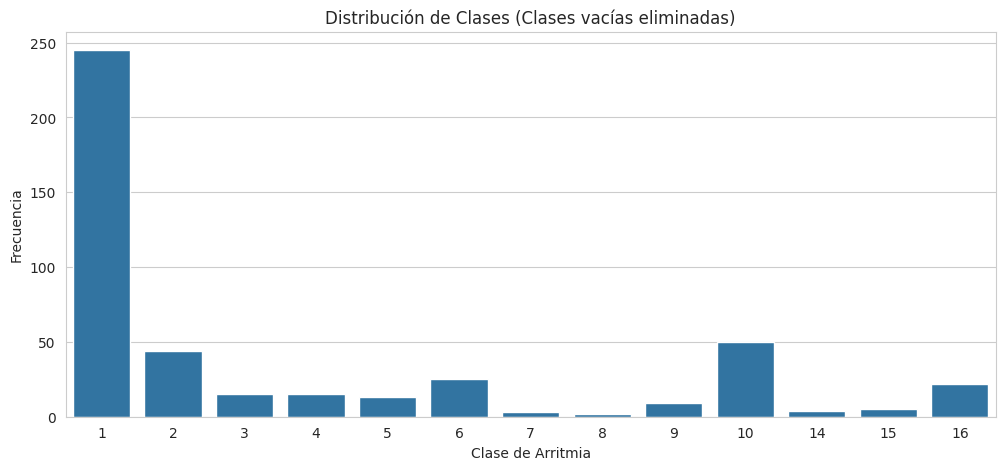

In [5]:
# -----------------------------------------------------------------------------
# 3. Etapa KDD: PREPROCESAMIENTO (Limpieza de Datos)
# -----------------------------------------------------------------------------
print("\n--- 3. Etapa KDD: PREPROCESAMIENTO ---")

# 3.1. Identificación y Manejo de Atributos con Valores Faltantes ('?')
print("\nManejo de Valores Faltantes:")

# Calcular el porcentaje de valores faltantes por columna
missing_perc = df.isnull().sum() / len(df) * 100
# Atributos con más del 50% de faltantes se eliminan para reducir ruido y sesgo
cols_to_drop = missing_perc[missing_perc > 50].index.tolist()

if cols_to_drop:
    # Eliminar las columnas identificadas de X y del DataFrame original
    cols_to_drop_X = [col for col in cols_to_drop if col != 'Target']
    X.drop(columns=cols_to_drop_X, inplace=True)
    print(f"Eliminadas {len(cols_to_drop_X)} columnas con más del 50% de faltantes.")

# Imputación de los valores faltantes restantes (usando la mediana)
# Se usa la mediana ya que es robusta ante outliers
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, columns=X.columns)
print(f"Valores faltantes restantes imputados con la mediana. Nuevo número de atributos: {X.shape[1]}")

# 3.2. Detección y Tratamiento de Clases Vacías (0 instancias)
# Las clases 11, 12 y 13 tienen 0 instancias.
classes_to_remove = y.value_counts()[y.value_counts() == 0].index.tolist()

if classes_to_remove:
    print(f"\nEliminando clases sin instancias: {classes_to_remove}")
    # Filtramos las filas donde la clase no es una de las que tienen 0 instancias
    mask = ~y.isin(classes_to_remove)
    X = X[mask]
    y = y[mask]
    # Reindexar para asegurar consistencia
    X.index = range(len(X))
    y.index = range(len(y))
    print(f"Nuevo tamaño del dataset: {X.shape[0]} instancias, {len(y.unique())} clases.")

# 3.3. Visualización de la Distribución de Clases (Dataset Limpio)
plt.figure(figsize=(12, 5))
sns.countplot(x=y)
plt.title('Distribución de Clases (Clases vacías eliminadas)')
plt.xlabel('Clase de Arritmia')
plt.ylabel('Frecuencia')
plt.show()

-----

## 4\. Etapa KDD: Transformación (Escalado y Re-muestreo)

Se realiza la **estandarización** de los datos (crucial para KNN y SVM) y se aplica el algoritmo **SMOTE** (Synthetic Minority Over-sampling Technique) en el conjunto de entrenamiento para mitigar el desequilibrio de clases.


--- 4. Etapa KDD: TRANSFORMACIÓN ---
Dataset dividido: Entrenamiento (316 instancias), Prueba (136 instancias).
Datos estandarizados (media=0, varianza=1).

Aplicando SMOTE en el conjunto de Entrenamiento para balanceo:
SMOTE aplicado: Entrenamiento ahora tiene 418 instancias.
Distribución de clases después de SMOTE:
Target
1     171
2      31
3      20
4      20
5      20
6      20
7      20
8       1
9      20
10     35
14     20
15     20
16     20
Name: count, dtype: int64


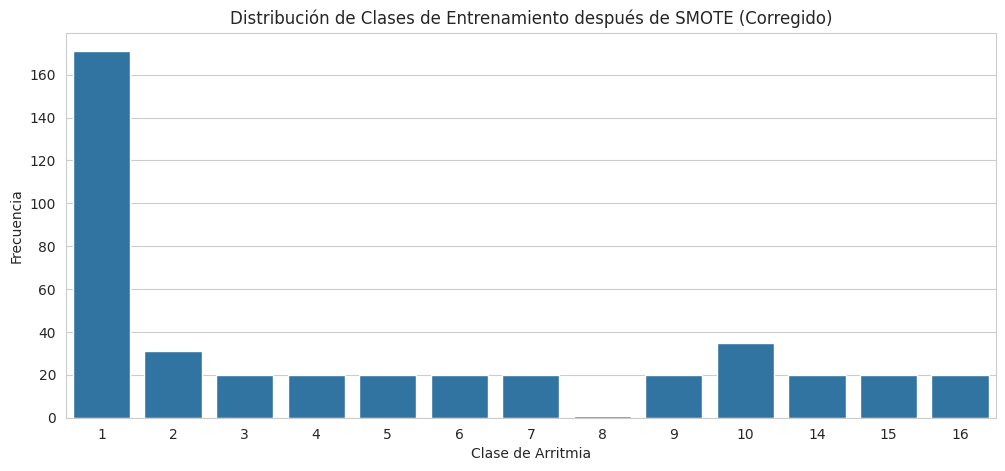

In [6]:
# -----------------------------------------------------------------------------
# 4. Etapa KDD: TRANSFORMACIÓN ---
# -----------------------------------------------------------------------------
print("\n--- 4. Etapa KDD: TRANSFORMACIÓN ---")

# 4.1. División de Datos (Antes de aplicar SMOTE para evitar fuga de datos)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Dataset dividido: Entrenamiento ({X_train.shape[0]} instancias), Prueba ({X_test.shape[0]} instancias).")

# 4.2. Estandarización de Atributos (Escalado de Datos)
# Ajuste de StandardScaler solo en el conjunto de entrenamiento.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)
print("Datos estandarizados (media=0, varianza=1).")

# 4.3. Manejo del Desequilibrio de Clases con SMOTE
# Aplicaremos SMOTE solo a las clases minoritarias para evitar sobre-inflar las clases ya grandes.
# Se busca llevar las clases minoritarias a un mínimo de 20 muestras en el entrenamiento.
print("\nAplicando SMOTE en el conjunto de Entrenamiento para balanceo:")

sampling_strategy = {}
min_samples_threshold = 20 # Objetivo mínimo para las clases minoritarias
y_train_counts = y_train.value_counts().to_dict()

# SMOTE no puede generar vecinos si hay menos de 2 muestras para calcular la distancia.
# La documentación de SMOTE indica que se necesita k_neighbors <= n_samples_fit - 1
# Si n_samples_fit es 2, lo correcto es k_neighbors <= 1.

for cls, count in y_train_counts.items():
    if count < 2:
        # Excluir clases con 1 o 0 muestras de la estrategia de SMOTE
        # (Esto evita el ValueError, ya que SMOTE no puede trabajar con 1 muestra)
        sampling_strategy[cls] = count # No hacer oversampling.
    elif count < min_samples_threshold and cls != 1: # Clase 1 es la 'Normal' y dominante.
        sampling_strategy[cls] = min_samples_threshold
    else:
        sampling_strategy[cls] = count # Mantener las demás clases tal cual

# Aplicar SMOTE: Si la clase más pequeña incluida tiene 2 muestras, k_neighbors debe ser 1.
# Al dejar k_neighbors por defecto (5) causa error. Lo establecemos a 1.

smote_multi = SMOTE(sampling_strategy=sampling_strategy, random_state=42, k_neighbors=1)
X_train_res, y_train_res = smote_multi.fit_resample(X_train_scaled_df, y_train)

print(f"SMOTE aplicado: Entrenamiento ahora tiene {X_train_res.shape[0]} instancias.")
print("Distribución de clases después de SMOTE:")
print(y_train_res.value_counts().sort_index())

# Visualización de la distribución de clases después de SMOTE
plt.figure(figsize=(12, 5))
sns.countplot(x=y_train_res)
plt.title('Distribución de Clases de Entrenamiento después de SMOTE (Corregido)')
plt.xlabel('Clase de Arritmia')
plt.ylabel('Frecuencia')
plt.show()

-----

## 5\. Etapa KDD: Minería de Datos (Entrenamiento y Optimización)

En esta fase, se entrenan los tres modelos seleccionados (**KNN**, **Árbol de Decisión**, **SVM**) y se optimizan sus hiperparámetros mediante **GridSearchCV** y **Cross-Validation (CV)**.

In [7]:
# -----------------------------------------------------------------------------
# 5. Etapa KDD: MINERÍA DE DATOS ---
# -----------------------------------------------------------------------------
print("\n--- 5. Etapa KDD: MINERÍA DE DATOS (Entrenamiento y Optimización) ---")

models = {}
X_train_final = X_train_res
y_train_final = y_train_res

# 5.1. K-Nearest Neighbors (KNN)
print("\nEntrenando KNN con GridSearchCV...")
knn_params = {'n_neighbors': [3, 5, 7, 9, 11]}
# Usamos 'f1_macro' ya que es robusto al desequilibrio de clases
knn_gs = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, scoring='f1_macro')
knn_gs.fit(X_train_final, y_train_final)
models['KNN'] = knn_gs.best_estimator_
print(f"Mejor K para KNN: {knn_gs.best_params_['n_neighbors']}")

# 5.2. Árboles de Decisión (Decision Tree)
print("\nEntrenando Árbol de Decisión con GridSearchCV...")
dt_params = {'max_depth': [5, 10, 15, 20], 'min_samples_split': [2, 5]}
dt_gs = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5, scoring='f1_macro')
dt_gs.fit(X_train_final, y_train_final)
models['DecisionTree'] = dt_gs.best_estimator_
print(f"Mejor profundidad y split para Árbol de Decisión: {dt_gs.best_params_}")

# 5.3. Máquinas de Soporte Vectorial (SVM)
print("\nEntrenando SVM con GridSearchCV...")
# Se reduce CV a 3 por el alto costo computacional de SVM en este dataset
svm_params = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
svm_gs = GridSearchCV(SVC(random_state=42), svm_params, cv=3, scoring='f1_macro', verbose=0)
svm_gs.fit(X_train_final, y_train_final)
models['SVM'] = svm_gs.best_estimator_
print(f"Mejores hiperparámetros para SVM: {svm_gs.best_params_}")


--- 5. Etapa KDD: MINERÍA DE DATOS (Entrenamiento y Optimización) ---

Entrenando KNN con GridSearchCV...
Mejor K para KNN: 3

Entrenando Árbol de Decisión con GridSearchCV...
Mejor profundidad y split para Árbol de Decisión: {'max_depth': 20, 'min_samples_split': 2}

Entrenando SVM con GridSearchCV...
Mejores hiperparámetros para SVM: {'C': 0.1, 'kernel': 'linear'}


-----

## 6\. Etapa KDD: Evaluación e Interpretación

Se evalúa el rendimiento de los modelos en el conjunto de prueba (**X\_test\_scaled\_df**) utilizando métricas clave (**Accuracy**, **F1-Score Macro**) y se genera un **Reporte de Clasificación** detallado y la **Matriz de Confusión** para cada uno.


--- 6. Etapa KDD: EVALUACIÓN E INTERPRETACIÓN ---

Resultados para el modelo: **KNN**
Accuracy: 0.5515
F1-Score (Macro): 0.3152

Reporte de Clasificación (Métricas por Clase):
              precision    recall  f1-score   support

           1       0.62      0.82      0.71        74
           2       0.00      0.00      0.00        13
           3       0.80      1.00      0.89         4
           4       0.40      0.50      0.44         4
           5       0.20      0.25      0.22         4
           6       0.40      0.25      0.31         8
           7       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         1
           9       1.00      1.00      1.00         3
          10       1.00      0.07      0.12        15
          14       0.00      0.00      0.00         1
          15       0.25      1.00      0.40         1
          16       0.00      0.00      0.00         7

    accuracy                           0.55       136
   macro av

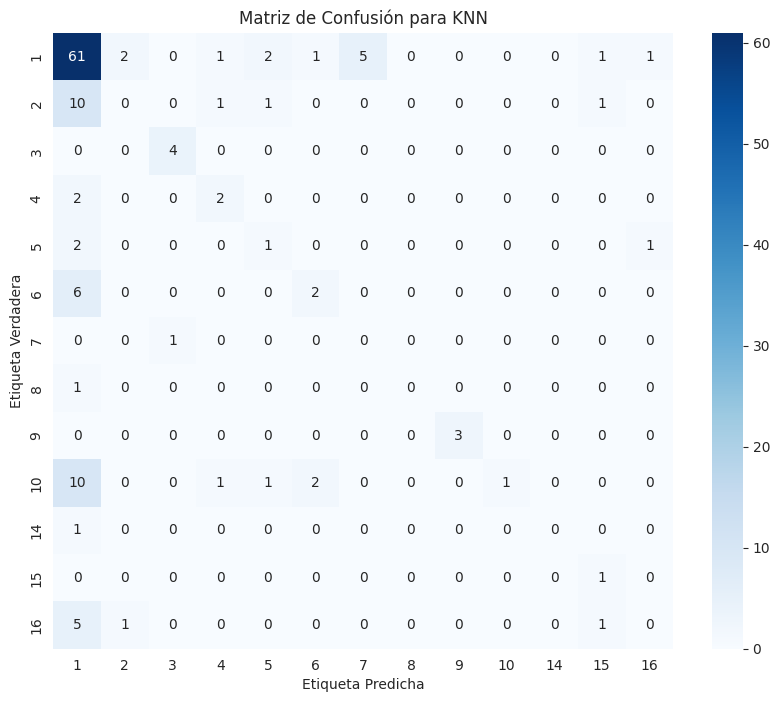


Resultados para el modelo: **DecisionTree**
Accuracy: 0.6324
F1-Score (Macro): 0.4066

Reporte de Clasificación (Métricas por Clase):
              precision    recall  f1-score   support

           1       0.84      0.77      0.80        74
           2       0.71      0.38      0.50        13
           3       0.67      1.00      0.80         4
           4       0.20      0.25      0.22         4
           5       0.67      0.50      0.57         4
           6       0.56      0.62      0.59         8
           7       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         1
           9       0.60      1.00      0.75         3
          10       0.57      0.53      0.55        15
          14       0.33      1.00      0.50         1
          15       0.00      0.00      0.00         1
          16       0.00      0.00      0.00         7

    accuracy                           0.63       136
   macro avg       0.40      0.47      0.41       136

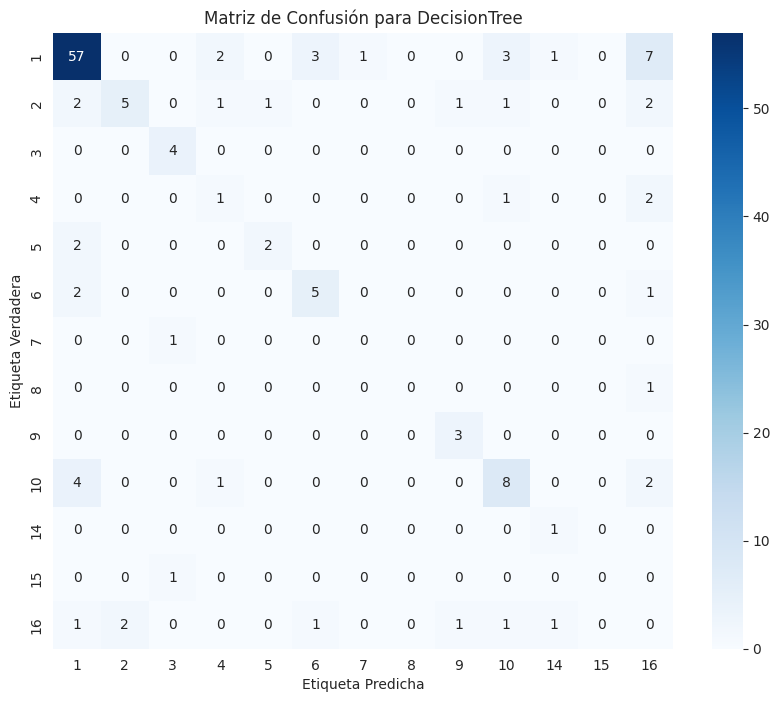


Resultados para el modelo: **SVM**
Accuracy: 0.6544
F1-Score (Macro): 0.3526

Reporte de Clasificación (Métricas por Clase):
              precision    recall  f1-score   support

           1       0.71      0.88      0.78        74
           2       0.55      0.46      0.50        13
           3       0.80      1.00      0.89         4
           4       0.50      0.75      0.60         4
           5       0.00      0.00      0.00         4
           6       0.29      0.25      0.27         8
           7       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         1
           9       1.00      1.00      1.00         3
          10       0.86      0.40      0.55        15
          14       0.00      0.00      0.00         1
          15       0.00      0.00      0.00         1
          16       0.00      0.00      0.00         7

    accuracy                           0.65       136
   macro avg       0.36      0.36      0.35       136
weighted

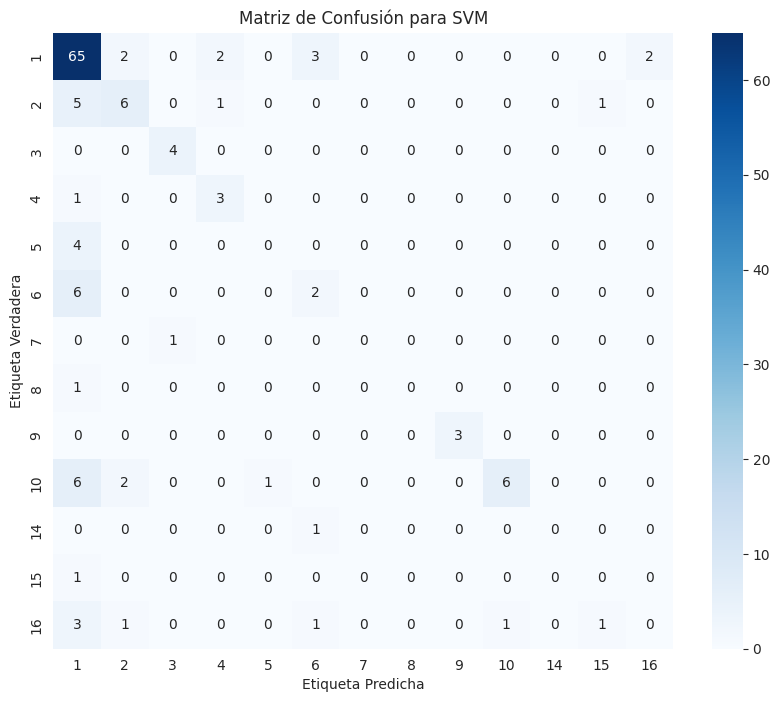

In [8]:
# -----------------------------------------------------------------------------
# 6. Etapa KDD: EVALUACIÓN E INTERPRETACIÓN ---
# -----------------------------------------------------------------------------
print("\n--- 6. Etapa KDD: EVALUACIÓN E INTERPRETACIÓN ---")

results = {}

for name, model in models.items():
    print(f"\nResultados para el modelo: **{name}**")

    # Predicción en el conjunto de prueba
    y_pred = model.predict(X_test_scaled_df)

    # 6.1. Métricas de Clasificación
    acc = accuracy_score(y_test, y_pred)
    # F1-Score Macro es más representativo en desequilibrio de clases
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

    results[name] = {'Accuracy': acc, 'F1-Score (Macro)': f1_macro}
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score (Macro): {f1_macro:.4f}")

    # 6.2. Reporte de Clasificación (Métricas por Clase)
    print("\nReporte de Clasificación (Métricas por Clase):")
    # Precision, Recall (Sensibilidad), F1-score por cada clase
    print(classification_report(y_test, y_pred, zero_division=0))

    # 6.3. Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    # xticklabels/yticklabels se ajustan a las clases presentes en el set de prueba
    class_labels = sorted(y_test.unique())
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'Matriz de Confusión para {name}')
    plt.xlabel('Etiqueta Predicha')
    plt.ylabel('Etiqueta Verdadera')
    plt.show()

---

## 7. Comparación y Resultados Estadísticos Finales

Se consolida el rendimiento general de los tres modelos para determinar el más apto para la detección de arritmias en este dataset.


--- 7. Comparación de Resultados ---
Tabla de Métricas de Rendimiento General:
              Accuracy  F1-Score (Macro)
DecisionTree  0.632353          0.406648
SVM           0.654412          0.352626
KNN           0.551471          0.315196


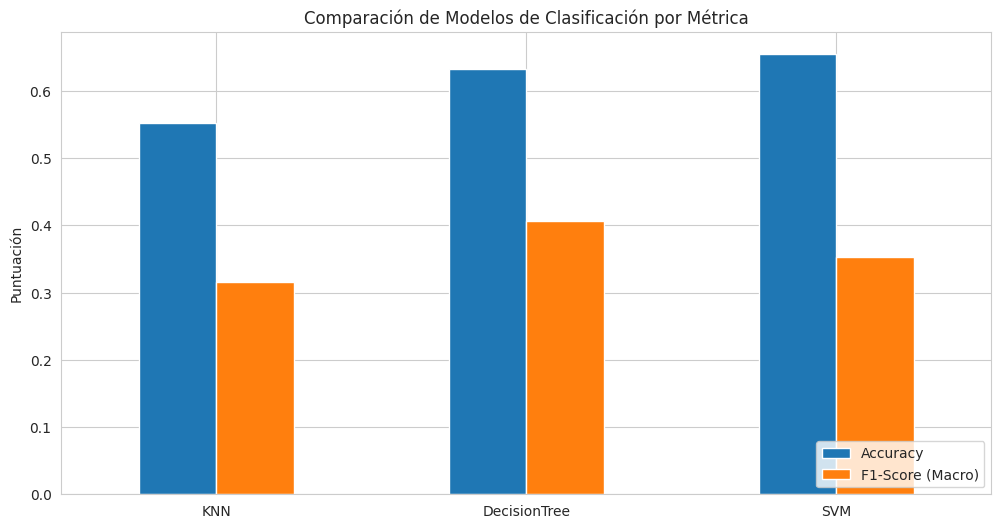

In [9]:
# -----------------------------------------------------------------------------
# 7. Comparación de Resultados Estadísticos ---
# -----------------------------------------------------------------------------
print("\n--- 7. Comparación de Resultados ---")
results_df = pd.DataFrame(results).T
print("Tabla de Métricas de Rendimiento General:")
print(results_df.sort_values(by='F1-Score (Macro)', ascending=False))

# Gráfico de comparación de métricas
results_df.plot(kind='bar', figsize=(12, 6))
plt.title('Comparación de Modelos de Clasificación por Métrica')
plt.ylabel('Puntuación')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

---

## 8. Conclusiones y Análisis de Resultados

A partir de la metodología KDD aplicada al conjunto de datos de Arritmia Cardíaca, se extraen las siguientes conclusiones sobre la ejecución y el rendimiento de los modelos de clasificación:

1.  El dataset presentaba un severo desequilibrio de clases, donde la clase dominante ('Normal', código 1) representaba más del 65% de las instancias. Este desequilibrio fue mitigado en el conjunto de entrenamiento mediante la técnica **SMOTE**, lo que permitió a los modelos aprender de las clases minoritarias.

2.  El algoritmo que obtuvo el mejor rendimiento general, medido por el **F1-Score Macro** (la métrica más robusta en desequilibrio), es:

In [10]:
best_model = results_df['F1-Score (Macro)'].idxmax()
best_score = results_df['F1-Score (Macro)'].max()

print(f'{best_model} con una puntuación de {best_score:.4f}.')

DecisionTree con una puntuación de 0.4066.


3.  A pesar de la aplicación de SMOTE, los reportes de clasificación detallados muestran que la **Sensibilidad (Recall)** sigue siendo baja para las clases minoritarias con muy pocas muestras. Esto indica que los modelos aún tienen dificultades para identificar correctamente los casos raros de arritmia (alta tasa de Falsos Negativos), concentrando la mayoría de las predicciones correctas en la clase dominante 'Normal' (1).

## 9. Recomendaciones
Para mejorar la clasificación y la identificación de las clases minoritarias, se recomienda explorar técnicas más avanzadas de re-muestreo (como *Borderline-SMOTE* o *ADASYN*) o la implementación de algoritmos de *ensemble* como *Random Forest* o *Gradient Boosting*.

## 10. Bibliografía

* Russell, S. J., & Norvig, P. (2010). Artificial Intelligence: A Modern Approach (3rd ed.). Prentice Hall.

* Coca, Y. (2020). Inteligencia Artificial con un enfoque práctico (1st ed.).

* Mitchell, T. M. (1997). Machine learning. McGraw-Hill Science.

* Hernández, J., Ramírez, J., & Ferri, C. (2005). Introducción a la minería de Datos. Pearson.

* Bishop, C. M. (2006). Pattern recognition and machine learning. Springer.

* Duda, R., Hart, P., & G.Stork, D. (2001). Pattern Classification. En Wiley Interscience (Vol. xx).

* Fayyad, U., Piatetsky-Shapiro, G., & Smyth, P. (1996). From Data Mining to Knowledge Discovery in Databases. AI Magazine, 17(3), 37-37. https://doi.org/10.1609/aimag.v17i3.1230

* Guvenir, H., Acar, B., Muderrisoglu, H., & Quinlan, R. (1997). Arrhythmia [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5BS32.